In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/creditwise_raw_data.csv")

In [3]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handle missing values

In [6]:
processed_df = df.copy()

In [7]:
# Handle missing values

cat_cols = processed_df.select_dtypes(include=["object"]).columns
num_cols = processed_df.select_dtypes(include=["number"]).columns

from sklearn.impute import SimpleImputer

target = "Loan_Approved"

cat_cols = processed_df.drop(columns=[target]).select_dtypes(include=["object"]).columns

num_cols = processed_df.drop(columns=[target]).select_dtypes(include=["number"]).columns

num_imp = SimpleImputer(strategy="mean")
processed_df[num_cols] = num_imp.fit_transform(processed_df[num_cols])

cat_imp = SimpleImputer(strategy="most_frequent")
processed_df[cat_cols] = cat_imp.fit_transform(processed_df[cat_cols])

In [11]:
processed_df.isnull().sum()

Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status      0
Age                    0
Marital_Status         0
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose           0
Property_Area          0
Education_Level        0
Gender                 0
Employer_Category      0
Loan_Approved         50
dtype: int64

In [9]:
processed_df[processed_df["Loan_Approved"].isnull()].head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
15,16.00,7311.0,1301.0,Salaried,42.0,Married,3.0,710.0,4.0,0.48,9908.0,24561.0,9120.0,72.0,Personal,Urban,Not Graduate,Female,Private,NaN
26,27.00,19912.0,5796.0,Contract,28.0,Single,1.0,568.0,1.0,0.16,16884.0,25060.0,11679.0,84.0,Personal,Urban,Graduate,Male,Government,NaN
100,101.00,8910.0,6960.0,Self-employed,23.0,Single,3.0,789.0,2.0,0.52,16450.0,32761.0,11412.0,36.0,Business,Urban,Graduate,Female,Government,NaN
122,123.00,5627.0,8044.0,Self-employed,30.0,Married,3.0,700.0,0.0,0.14,1184.0,39618.0,17292.0,72.0,Home,Rural,Graduate,Male,Private,NaN
191,501.22,11208.0,1165.0,Salaried,43.0,Single,2.0,781.0,1.0,0.50,13579.0,41797.0,19907.0,72.0,Education,Rural,Not Graduate,Female,MNC,NaN


In [10]:
processed_df["Loan_Approved"].value_counts(dropna=False)

Loan_Approved
No     652
Yes    298
NaN     50
Name: count, dtype: int64

## EDA - Exploratory Data Analysis

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

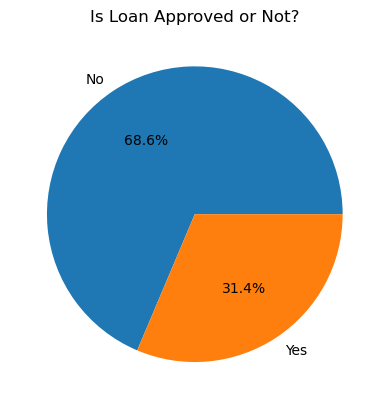

[Text(0, 0, '621'), Text(0, 0, '379')]

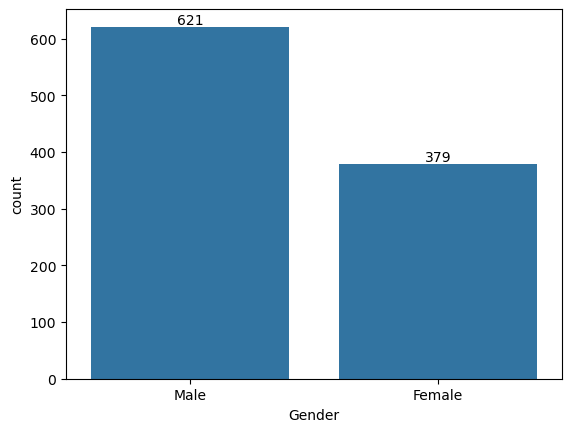

In [21]:
# How balanced our classes are?

classes_count = processed_df[target].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan Approved or Not?")
plt.show()

# Analyze categories
gender_cnt = processed_df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

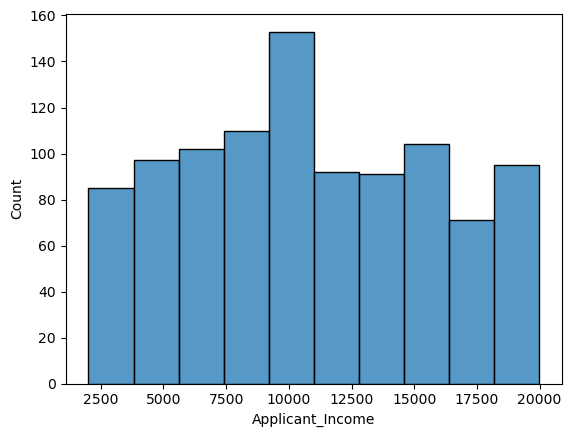

In [22]:
# Analyze Income

sns.histplot(
    data=processed_df,
    x = "Applicant_Income",
    bins=10
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

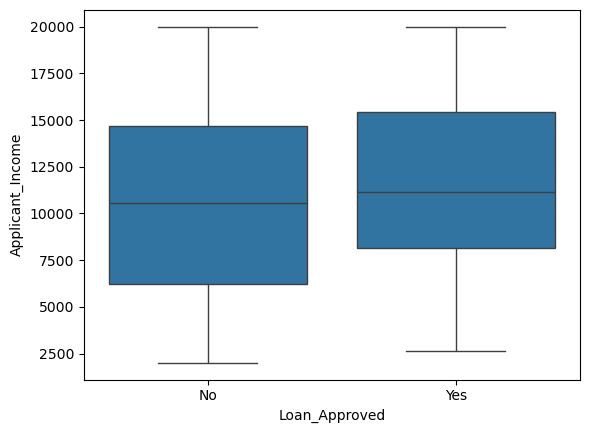

In [23]:
# Outlier check - box plots

sns.boxplot(
    data=processed_df,
    x="Loan_Approved",
    y="Applicant_Income"
)

In [24]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

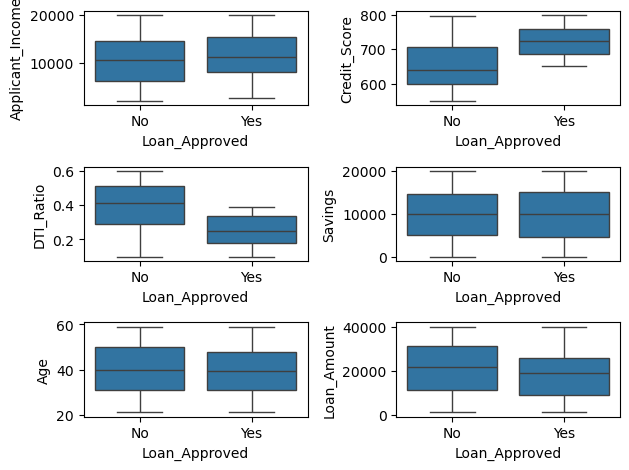

In [29]:
fig, axes = plt.subplots(3,2)

sns.boxplot(ax=axes[0,0], data=processed_df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=processed_df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=processed_df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=processed_df, x="Loan_Approved", y="Savings")
sns.boxplot(ax=axes[2,0], data=processed_df, x="Loan_Approved", y="Age")
sns.boxplot(ax=axes[2,1], data=processed_df, x="Loan_Approved", y="Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

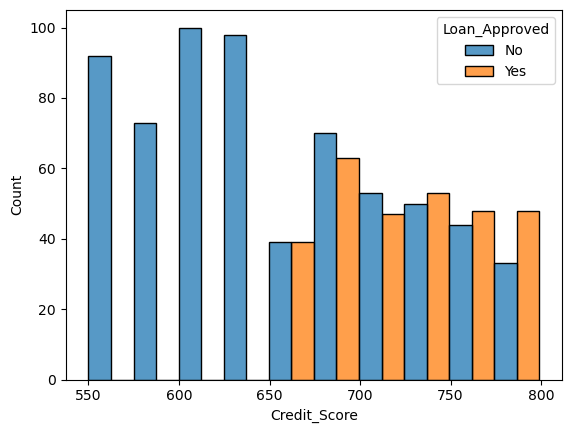

In [31]:
# Credit Score with Loan Approved

sns.histplot(
    data=processed_df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=10,
    multiple="dodge"
)

In [32]:
# Remove applicant id

processed_df = processed_df.drop("Applicant_ID", axis=1)

## Encoding

In [36]:
processed_df["Education_Level"].unique()

array(['Not Graduate', 'Graduate'], dtype=object)

In [37]:
from sklearn.preprocessing import OneHotEncoder

# Label encoding
processed_df["Education_Level"] = processed_df["Education_Level"].map({
    "Not Graduate": 0,
    "Graduate": 1
})
# One Hot encoding for nominal features
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(processed_df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=processed_df.index)
processed_df = pd.concat([processed_df.drop(columns=cols), encoded_df], axis=1)

In [39]:
processed_df.shape

(1000, 28)

## Correlation Heatmap

In [40]:
num_cols = processed_df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

In [41]:
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [51]:
labeled_df = processed_df.dropna(subset=["Loan_Approved"]).copy()

labeled_df["Loan_Approved"] = labeled_df["Loan_Approved"].map({
    "No": 0,
    "Yes": 1
})

num_cols = labeled_df.select_dtypes(include="number")
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.476937
Applicant_Income                   0.125003
Employer_Category_MNC              0.073448
Education_Level                    0.056283
Marital_Status_Single              0.037586
Loan_Purpose_Personal              0.035519
Collateral_Value                   0.027377
Property_Area_Urban                0.025731
Coapplicant_Income                 0.009077
Loan_Purpose_Home                  0.003108
Employer_Category_Private          0.000707
Employment_Status_Self-employed   -0.001572
Loan_Purpose_Education            -0.011940
Property_Area_Semiurban           -0.014259
Dependents                        -0.016340
Savings                           -0.016863
Age                               -0.027362
Employer_Category_Unemployed      -0.028736
Existing_Loans                    -0.035395
Employer_Category_Government      -0.039135
Employment_Status_Salaried        -0.046912
Employment_Status_Unemployed    

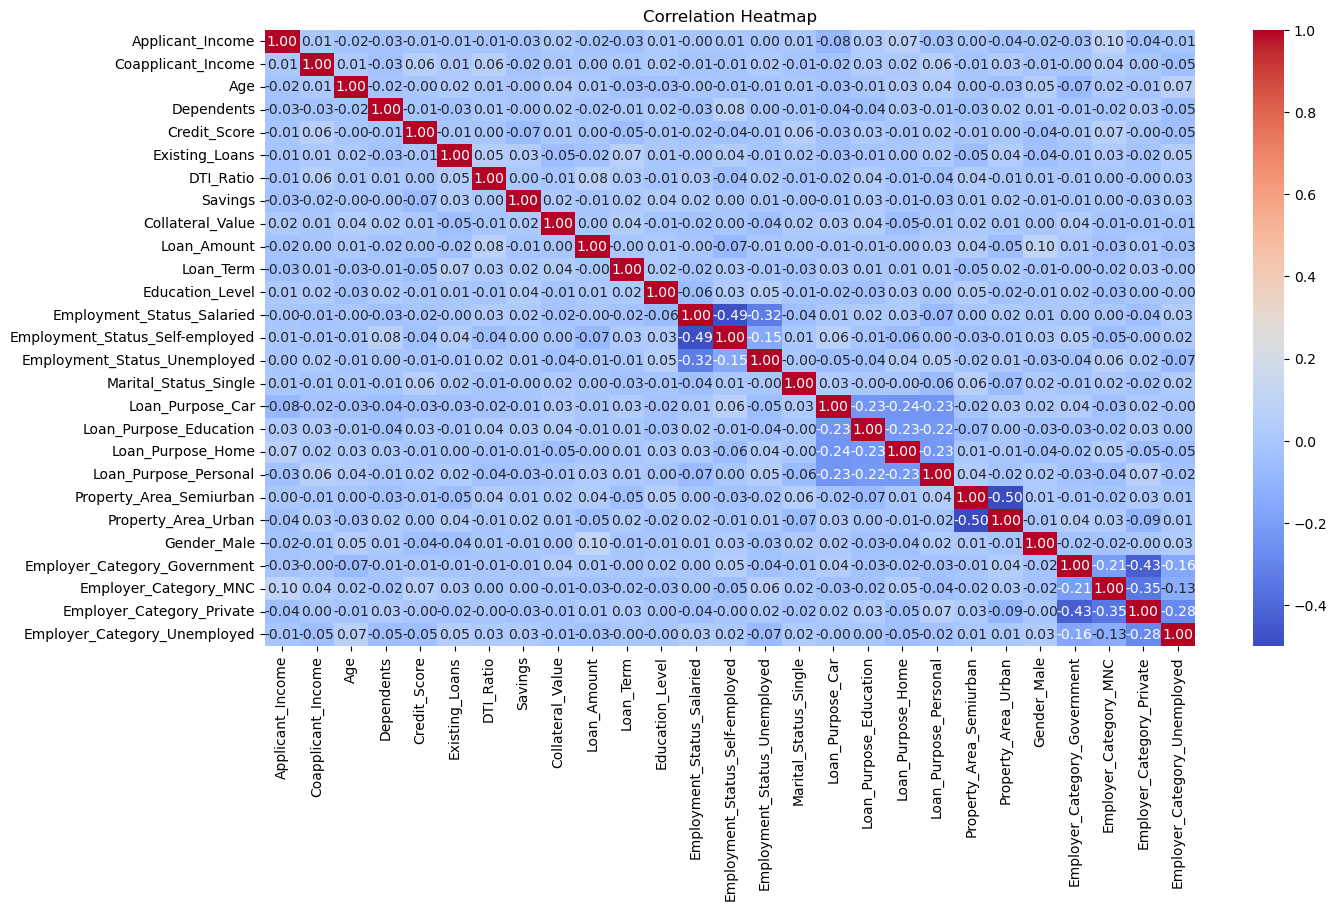

In [56]:
plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()